# EDA & Feature Engineering
Walmart Store Sales Forecasting eda and feature engineering.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.preprocessing import load_raw, build_features

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (14, 5)

## 1. Load Raw Data

In [2]:
train, test, features, stores = load_raw()

print('train:', train.shape)
print('test: ', test.shape)
train.head()

train: (421570, 5)
test:  (115064, 4)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [3]:
features.tail()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
8185,45,2013-06-28,76.05,3.639,4842.29,975.03,3.00,2449.97,3169.69,NaN,NaN,False
8186,45,2013-07-05,77.50,3.614,9090.48,2268.58,582.74,5797.47,1514.93,NaN,NaN,False
8187,45,2013-07-12,79.37,3.614,3789.94,1827.31,85.72,744.84,2150.36,NaN,NaN,False
8188,45,2013-07-19,82.84,3.737,2961.49,1047.07,204.19,363.00,1059.46,NaN,NaN,False
8189,45,2013-07-26,76.06,3.804,212.02,851.73,2.06,10.88,1864.57,NaN,NaN,False


## 2. Basic Statistics & Missing Values

In [4]:
print(train.describe())
print('\nMissing values:')
print(features.isnull().sum())

               Store           Dept                        Date   Weekly_Sales
count  421570.000000  421570.000000                      421570  421570.000000
mean       22.200546      44.260317  2011-06-18 08:30:31.963375   15981.258123
min         1.000000       1.000000         2010-02-05 00:00:00   -4988.940000
25%        11.000000      18.000000         2010-10-08 00:00:00    2079.650000
50%        22.000000      37.000000         2011-06-17 00:00:00    7612.030000
75%        33.000000      74.000000         2012-02-24 00:00:00   20205.852500
max        45.000000      99.000000         2012-10-26 00:00:00  693099.360000
std        12.785297      30.492054                         NaN   22711.183519

Missing values:
Store              0
Date               0
Temperature        0
Fuel_Price         0
MarkDown1       4158
MarkDown2       5269
MarkDown3       4577
MarkDown4       4726
MarkDown5       4140
CPI              585
Unemployment     585
IsHoliday          0
dtype: int64


## 3. Seasonality & Trends

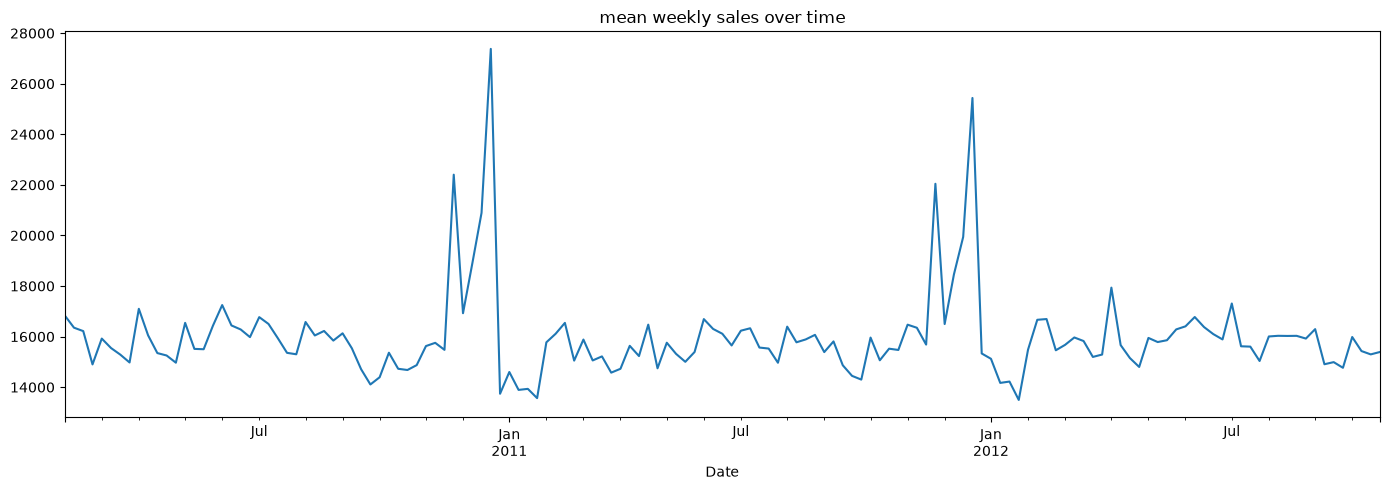

In [5]:
weekly = train.groupby('Date')['Weekly_Sales'].mean()
weekly.plot(title='mean weekly sales over time')
plt.tight_layout()

## 4. Autocorrelation & Partial Autocorrelation Analysis

ACF shows the correlation between the series and its own lags (direct + indirect effects), while PACF isolates the direct effect of each lag after removing the influence of shorter lags. These plots help identify seasonality and AR/MA order for models like ARIMA/SARIMA.

We use lags up to 52 (one year of weekly data) to check for yearly seasonality, and run an ADF test to check stationarity.

ADF Statistic: -5.9308
p-value: 0.0000


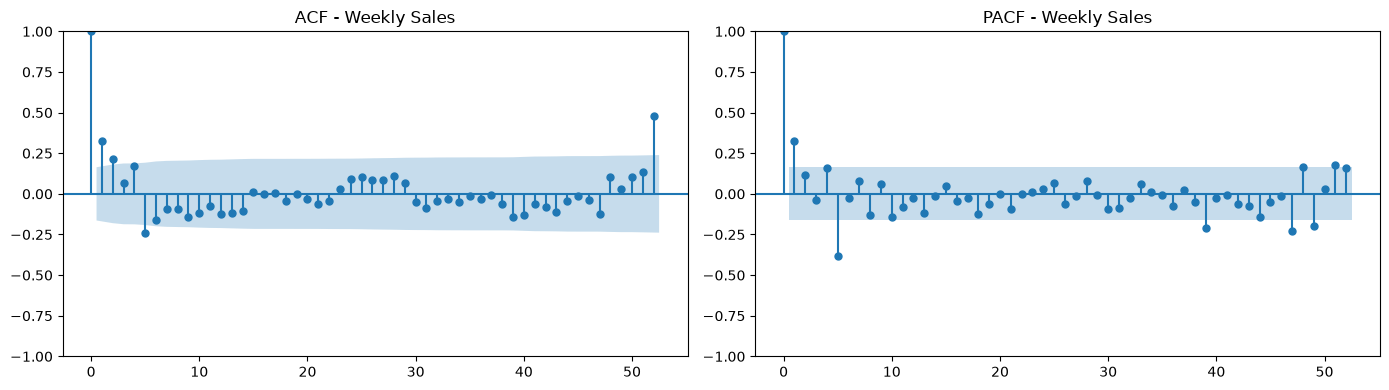

In [6]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

adf_raw = adfuller(weekly)
print(f'ADF Statistic: {adf_raw[0]:.4f}')
print(f'p-value: {adf_raw[1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(weekly, lags=52, ax=axes[0])
axes[0].set_title('ACF - Weekly Sales')
plot_pacf(weekly, lags=52, ax=axes[1], method='ywm')
axes[1].set_title('PACF - Weekly Sales')
plt.tight_layout()

The ADF test rejects the unit-root null (p << 0.05), so the raw series is stationary in the mean-reversion sense — there's no strong trend. However, the ACF shows a clear spike around lag 52 (~0.48), confirming yearly seasonality, and the PACF cuts off sharply after lag 1-2, suggesting a low-order AR component on top of the seasonal effect.

Since the seasonality is the dominant remaining structure, we apply a seasonal difference (lag 52) instead of a first difference, and re-check ACF/PACF/ADF.

ADF Statistic (seasonally differenced): -7.3988
p-value (seasonally differenced): 0.0000


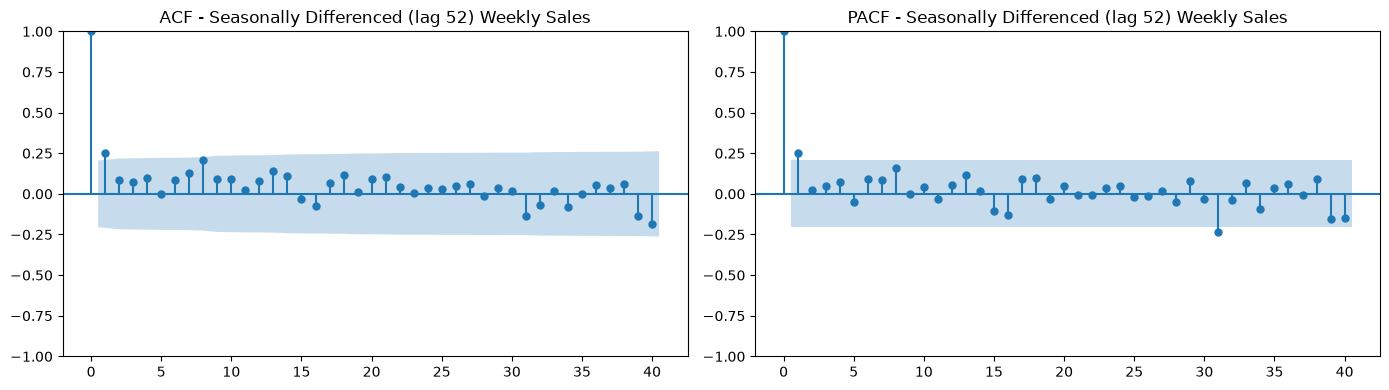

In [7]:
weekly_seasonal_diff = weekly.diff(52).dropna()

adf_sdiff = adfuller(weekly_seasonal_diff)
print(f'ADF Statistic (seasonally differenced): {adf_sdiff[0]:.4f}')
print(f'p-value (seasonally differenced): {adf_sdiff[1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(weekly_seasonal_diff, lags=40, ax=axes[0])
axes[0].set_title('ACF - Seasonally Differenced (lag 52) Weekly Sales')
plot_pacf(weekly_seasonal_diff, lags=40, ax=axes[1], method='ywm')
axes[1].set_title('PACF - Seasonally Differenced (lag 52) Weekly Sales')
plt.tight_layout()

## 5. Holiday Distribution

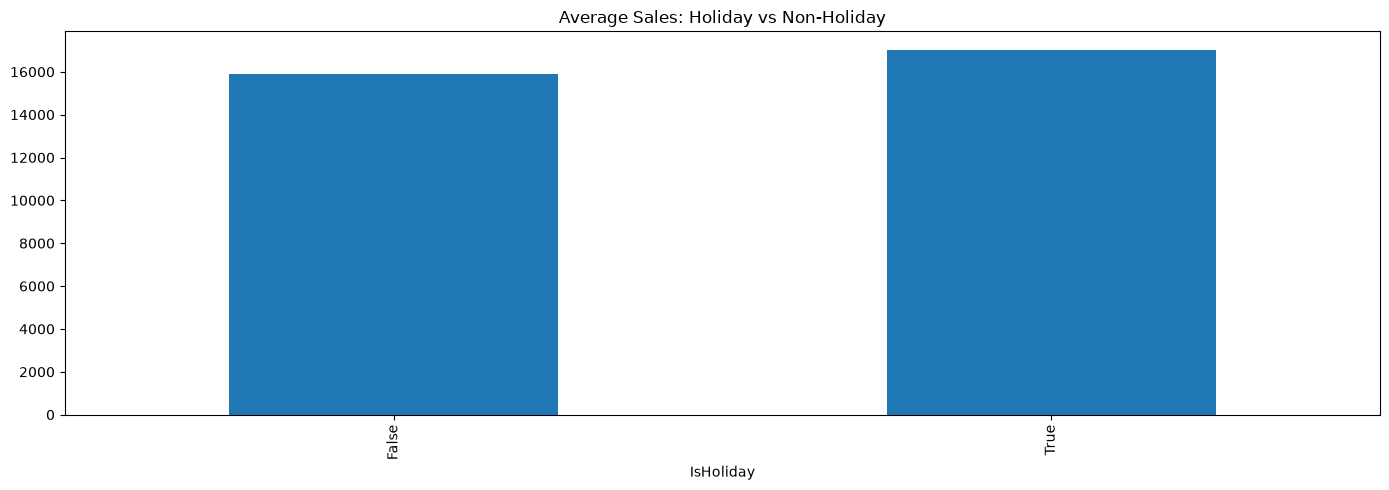

In [8]:
train.groupby('IsHoliday')['Weekly_Sales'].mean().plot(kind='bar', title='Average Sales: Holiday vs Non-Holiday')
plt.tight_layout()

## 6. Merge & Feature Engineering

In [9]:
train_full = build_features(train, features, stores)
test_full = build_features(test, features, stores)

print(train_full.shape)
train_full.head()

(421570, 19)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Week,Month,Year
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,A,151315,5,2,2010
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,A,151315,6,2,2010
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,A,151315,7,2,2010
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,A,151315,8,2,2010
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,A,151315,9,3,2010


## 7. Save Processed Data

In [10]:
train_full.to_csv('data/processed/train_processed.csv', index=False)
test_full.to_csv('data/processed/test_processed.csv', index=False)